# 011 — Binary Portfolio Optimization via QUBO v 1.3

#### Change - Added enhanced fetch asset feature 

## Admin

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import pickle
import matplotlib.pyplot as plt
import Quantum_Optimization_Functions as qof 

from tabulate import tabulate
import environment as envir

from qubo_functions import (
    compute_expected_return_vector,
    compute_covariance_matrix,
    build_qubo_matrix_mean_variance,
    generate_all_binary_portfolios,
    evaluate_all_binary_portfolios,
    find_optimal_portfolio_by_energy,
    export_qubo_terms_for_qaoa
)

In [2]:
data, headers = envir.environment_state()
print(tabulate(data, headers=headers))

System/Library           Version
-----------------------  ---------
Python                   3.10.9
numpy                    2.2.6
torch                    2.9.1
matplotlib               3.10.8
seaborn                  0.13.2
qiskit                   1.4.4
qiskit_machine_learning  0.8.4
yfinance                 1.2.0


### Notebook Parameters 

In [3]:
Target_Tickers = [
    "AAPL",
    "IBM",
    "JNJ",
    "CVS"
]

START_DATE = "2020-01-01"
END_DATE = "2025-01-01"

RISK_AVERSION = 0.5

print_flag = True 

### Fetch Market Data 

In [4]:
# if you want just a random sample, omit the companies_list and provide a sample size 
# summary_df, Asset_Returns_DataFrame = qof.get_assets(sample_size = 5)

# otherwise make sure you have a companies_list, start and end date 
summary_df, returns_df = qof.get_assets(companies_list = Target_Tickers, start_date=START_DATE, end_date=END_DATE)

Asset_Names = returns_df.columns
Number_of_Assets = returns_df.shape[1] 

# Asset_Returns_DataFrame = Asset_Returns_DataFrame.reset_index(drop=True)

if print_flag: 
    print(returns_df.head())

                AAPL       IBM       JNJ       CVS
Date                                              
2020-01-03 -0.009722 -0.007975 -0.011578 -0.007956
2020-01-06  0.007968 -0.001787 -0.001248  0.003942
2020-01-07 -0.004703  0.000671  0.006107 -0.003791
2020-01-08  0.016086  0.008346 -0.000138 -0.012503
2020-01-09  0.021241  0.010568  0.002966  0.002753


### Compute Mean-Variance Matrix 

In [5]:
Expected_Return_Vector = compute_expected_return_vector(returns_df)

Sigma_Covariance_Matrix = compute_covariance_matrix(returns_df)

In [6]:
# Display matricies 

if print_flag: 
    print("Expected Returns")
    print(Expected_Return_Vector)

    print("\nCovariance Matrix")
    print(Sigma_Covariance_Matrix)

Expected Returns
[ 1.15745738e-03  5.65255162e-04  6.94732284e-05 -2.12780453e-04]

Covariance Matrix
[[3.98286266e-04 1.34429353e-04 9.28265508e-05 1.13966117e-04]
 [1.34429353e-04 2.86334050e-04 1.00528109e-04 1.29964490e-04]
 [9.28265508e-05 1.00528109e-04 1.54291276e-04 1.01518272e-04]
 [1.13966117e-04 1.29964490e-04 1.01518272e-04 3.68772307e-04]]


### Build QUBO matrix 

In [7]:
Q_Matrix = build_qubo_matrix_mean_variance(
    Sigma_Covariance_Matrix=Sigma_Covariance_Matrix,
    Expected_Return_Vector=Expected_Return_Vector,
    Risk_Aversion_Parameter=RISK_AVERSION
)

In [8]:
if print_flag: 
    print(pd.DataFrame(Q_Matrix, index=Asset_Names, columns=Asset_Names))

          AAPL       IBM       JNJ       CVS
AAPL -0.000958  0.000067  0.000046  0.000057
IBM   0.000067 -0.000422  0.000050  0.000065
JNJ   0.000046  0.000050  0.000008  0.000051
CVS   0.000057  0.000065  0.000051  0.000397


### Generate Binary Portfolios 

In [9]:
Number_of_Assets = len(Asset_Names)

Binary_Portfolios = generate_all_binary_portfolios(Number_of_Assets)

# remove empty portfolio
Binary_Portfolios = Binary_Portfolios[1:]

In [10]:
#  Display number of portfolios 
if print_flag: 
    print("Number of portfolios:", len(Binary_Portfolios))

Number of portfolios: 15


### Portfolio Evaluation 

In [11]:
Evaluation_DataFrame = evaluate_all_binary_portfolios(
    Binary_Portfolios=Binary_Portfolios,
    Q_Matrix=Q_Matrix,
    Expected_Return_Vector=Expected_Return_Vector,
    Sigma_Covariance_Matrix=Sigma_Covariance_Matrix,
    Asset_Names=Asset_Names
)

In [12]:
# Display Result 
if print_flag: 
    print(Evaluation_DataFrame.head())

  Binary_Portfolio    Energy  Portfolio_Return  Portfolio_Risk  AAPL_Included  \
0     (0, 0, 0, 1)  0.000397         -0.000213        0.000369              0   
1     (0, 0, 1, 0)  0.000008          0.000069        0.000154              0   
2     (0, 0, 1, 1)  0.000506         -0.000143        0.000726              0   
3     (0, 1, 0, 0) -0.000422          0.000565        0.000286              0   
4     (0, 1, 0, 1)  0.000105          0.000352        0.000915              0   

   IBM_Included  JNJ_Included  CVS_Included  
0             0             0             1  
1             0             1             0  
2             0             1             1  
3             1             0             0  
4             1             0             1  


### Find Optimal Portfolio 

In [13]:
Optimal_Portfolio = find_optimal_portfolio_by_energy(
    Evaluation_DataFrame
)

if print_flag: 
    print(Optimal_Portfolio) 

Binary_Portfolio    (1, 1, 0, 0)
Energy                 -0.001246
Portfolio_Return        0.001723
Portfolio_Risk          0.000953
AAPL_Included                  1
IBM_Included                   1
JNJ_Included                   0
CVS_Included                   0
Name: 11, dtype: object


In [14]:
if print_flag: 
    print(Q_Matrix)

[[-9.58314250e-04  6.72146764e-05  4.64132754e-05  5.69830585e-05]
 [ 6.72146764e-05 -4.22088137e-04  5.02640546e-05  6.49822450e-05]
 [ 4.64132754e-05  5.02640546e-05  7.67240942e-06  5.07591359e-05]
 [ 5.69830585e-05  6.49822450e-05  5.07591359e-05  3.97166607e-04]]


### Export QUBO for QAOA analysis 

In [15]:
QUBO_Terms = export_qubo_terms_for_qaoa(Q_Matrix)

if print_flag: 
    print(QUBO_Terms)

{'Q_Matrix': array([[-9.58314250e-04,  6.72146764e-05,  4.64132754e-05,
         5.69830585e-05],
       [ 6.72146764e-05, -4.22088137e-04,  5.02640546e-05,
         6.49822450e-05],
       [ 4.64132754e-05,  5.02640546e-05,  7.67240942e-06,
         5.07591359e-05],
       [ 5.69830585e-05,  6.49822450e-05,  5.07591359e-05,
         3.97166607e-04]]), 'linear_terms': {0: -0.0009583142497374476, 1: -0.0004220881367937734, 2: 7.672409420888689e-06, 3: 0.000397166606573783}, 'quadratic_terms': {(0, 1): 6.72146764154191e-05, (0, 2): 4.6413275409642857e-05, (0, 3): 5.698305845519228e-05, (1, 2): 5.026405459039712e-05, (1, 3): 6.498224497948901e-05, (2, 3): 5.075913588845949e-05}}


In [16]:
# Save the QUBO_Terms 
fileOut = "../data/QUBO_Terms.pkl"

with open(fileOut, "wb") as f:
    pickle.dump(QUBO_Terms, f)

### Print the diagnostic graphs 

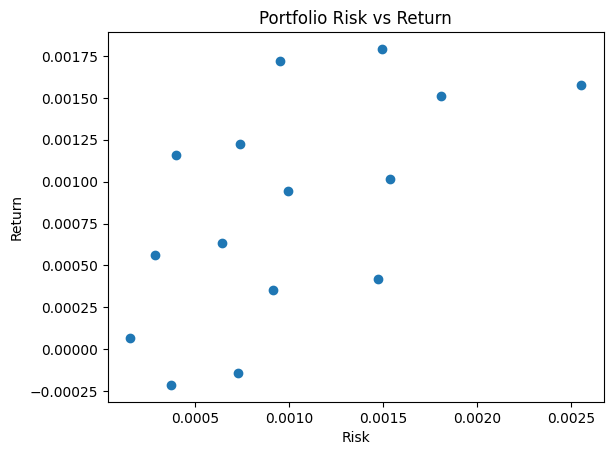

In [17]:
plt.scatter(
    Evaluation_DataFrame["Portfolio_Risk"],
    Evaluation_DataFrame["Portfolio_Return"]
)

plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Portfolio Risk vs Return")
plt.show()